Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

# Path to PE result file

In [2]:
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_1_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection_params_TEOB_chi0_9_ecc0_1_samples.dat"
# result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
# injection_file = "/Users/arif/Desktop/injection.dat"

# Postprocess the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [3]:
from gw_eccentricity.postprocess import PostProcessForBilby

/Users/arif/gw_eccentricity/gw_eccentricity/load_data.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [4]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

## Instantiate PostProcessForBilby class

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [6]:
# If  None, it works with the full posterior. We can work with only the relevant columns
parameter_columns = ["mass_1", "mass_2", "spin_1z", "spin_2z", "luminosity_distance", "minimum_frequency", "eccentricity", "mean_per_ano"]

egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_extra_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file,
                              parameter_columns=parameter_columns)

15:20 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


## Looking at the original posteriors

In [7]:
egwBilby.posterior

,mass_1,mass_2,spin_1z,spin_2z,luminosity_distance,minimum_frequency,eccentricity,mean_per_ano
0,57.672870,57.252479,0.870167,0.798733,1887.854670,10.0,0.003989,0.543482
1,59.499236,56.325833,0.780196,0.869048,1335.371576,10.0,0.002331,5.713039
2,58.514434,57.345206,0.850544,0.823274,1898.951510,10.0,0.001240,2.610911
3,59.119175,56.295871,0.825887,0.857436,1692.750621,10.0,0.023265,5.928536
4,58.702867,56.710941,0.842600,0.872537,1796.720835,10.0,0.031768,5.689220
...,...,...,...,...,...,...,...,...
16950,61.413996,57.720500,0.881558,0.892571,1872.201111,10.0,0.089138,4.975789
16951,61.265802,57.335984,0.890185,0.882906,1661.906177,10.0,0.081675,4.183263
16952,59.617784,58.298034,0.878334,0.867660,1803.001520,10.0,0.094222,4.566953
16953,60.155117,58.363542,0.888107,0.873803,1740.257118,10.0,0.071962,3.702541


We can also load the injection in case we are doing an injection using model waveform.

In [8]:
injection = egwBilby.get_injection()

In [9]:
data_dict = egwBilby.get_injection_data_dict()

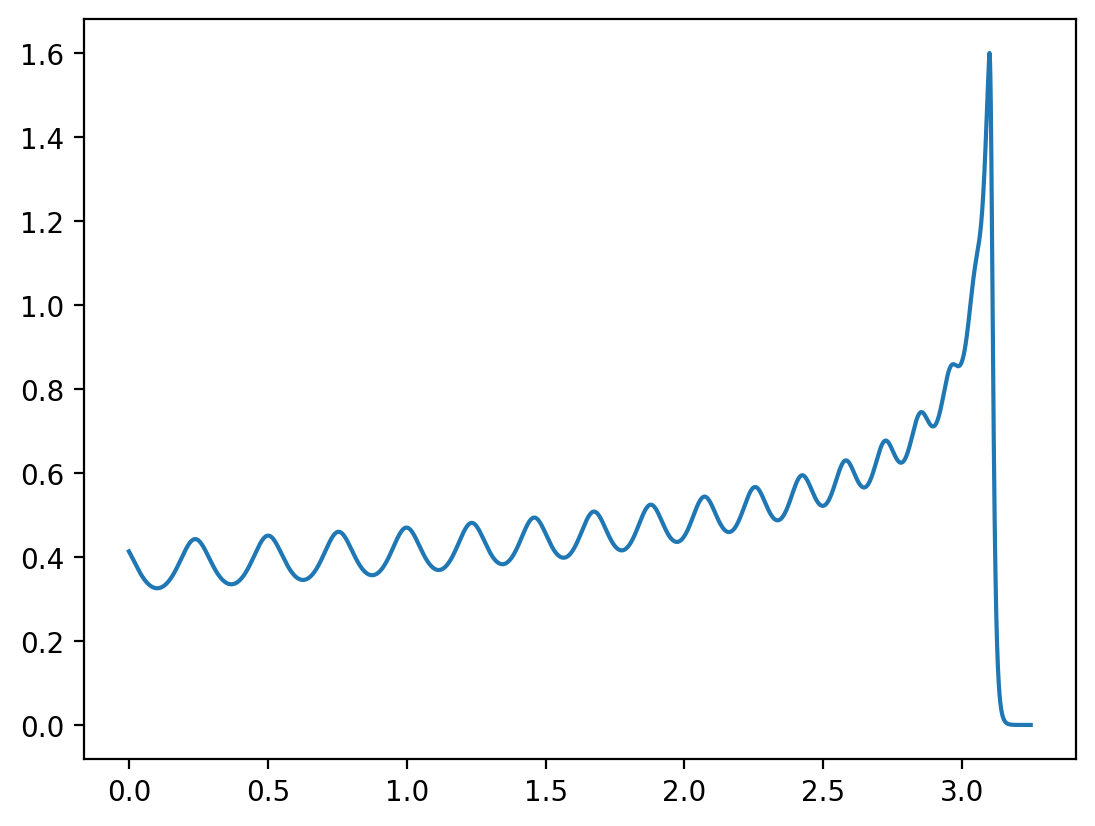

In [10]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

Finally plot the model posterior

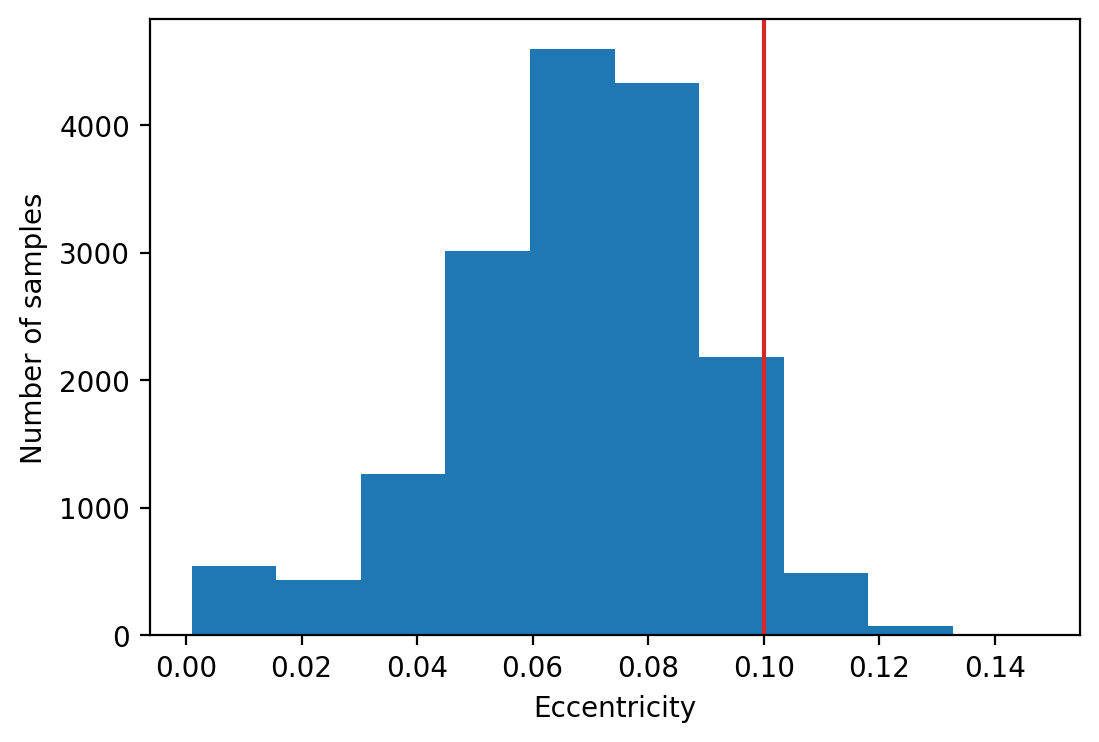

In [11]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

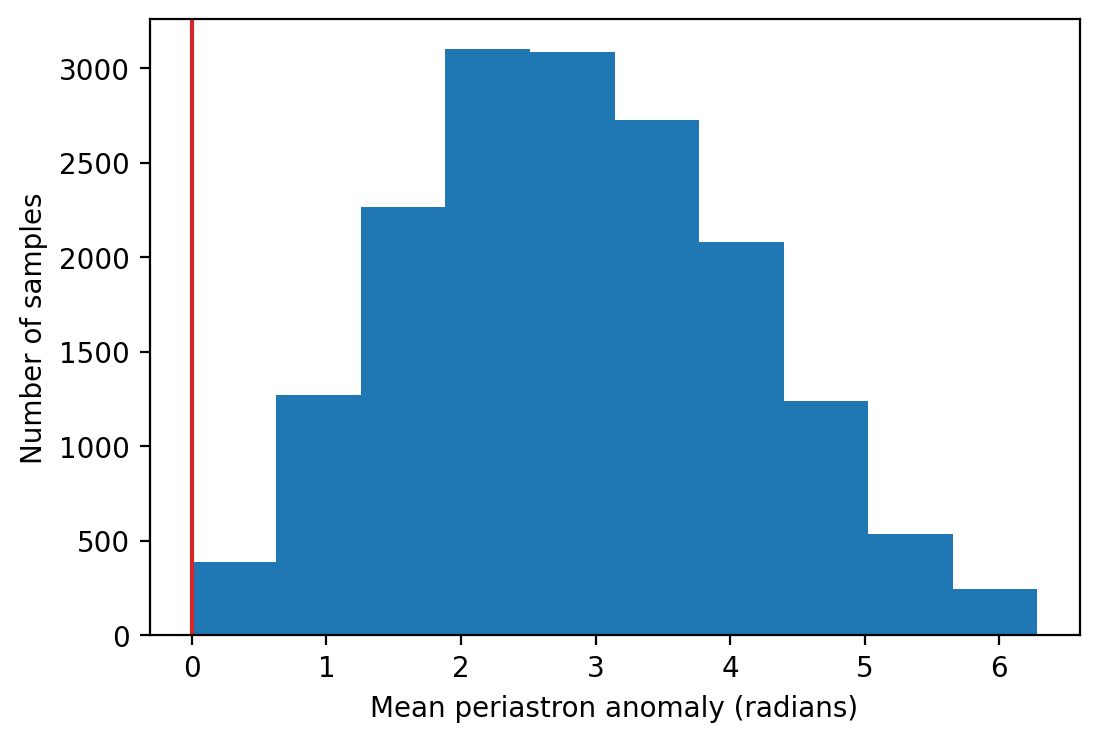

In [12]:
fig, ax = egwBilby.plot_mean_per_ano_posterior(**{"bins": 10})
ax.axvline(injection["mean_per_ano"], c="tab:red")

## Getting the allowed range of reference frequencies to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [13]:
import random

In [14]:
# we can use a subset of the samples to save time
samples = range(1000) #random.sample(range(0, len(egwBilby.posterior)), k=1000)

In [15]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    # "omega_gw_extrema_interpolation_method": "spline"
}}
n_jobs = 6

In [16]:
fref_bounds_result = egwBilby.get_fref_bounds(
    samples=samples,
    method=method,
    n_jobs=n_jobs,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)
print("Allowed range of reference frequencies are: ", fref_bounds_result.get_minmax_fref())

Getting fref bounds: 0it [00:00, ?it/s]/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: div

Allowed range of reference frequencies are:  (np.float64(9.084302296173474), np.float64(9.026488048808366))


The range of allowed reference frequencies comes from the samples where eccentricity measurement is successfull. We can get a summary of how many samples were successfully processed.

In [17]:
fref_bounds_result.get_summary()["success_percentage"]

98.5

We can also view the full result as a DataFrame

In [18]:
fref_bounds_result.to_dataframe()

,sample_index,status,fref_min,fref_max,error_message
0,0,success,8.939451,12.537668,None
1,1,success,8.947095,10.276723,None
2,2,success,8.901438,11.207611,None
3,3,success,8.983976,17.611660,None
4,4,success,9.000606,19.951132,None
...,...,...,...,...,...
995,995,success,8.900457,23.230405,None
996,996,success,8.960205,23.657321,None
997,997,success,8.897689,28.916292,None
998,998,success,8.942037,23.503057,None


## Postprocessing

We can postprocess a subset of the smaples or all the samples using the following method

In [19]:
import time

In [20]:
fref = 10
t_start = time.perf_counter()
samples = range(1000) #random.sample(range(0, len(egwBilby.posterior)), k=1000)
egwBilby.postprocess(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Postprocessing samples: 24it [00:00, 86.99it/s] Sample {'mass_1': 64.31611634741942, 'mass_2': 54.10445191029379, 'spin_1z': 0.8642571245649159, 'spin_2z': 0.8899500902216075, 'luminosity_distance': 1963.0090363226814, 'minimum_frequency': 10.0, 'eccentricity': 0.002278640854035012, 'mean_per_ano': 4.813454388571689} failed: Number of pericenters found = 0.
Can not build frequency interpolant through the pericenters.
It's possible that the eccentricity is too small for the Amplitude method to detect the pericenters. Try one of ['ResidualAmplitude', 'AmplitudeFits'] which should work even for a very small eccentricity.
Postprocessing samples: 48it [00:00, 42.31it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:2767: UserWarning: egw(t) is nonmonotonic at 2.6401367187499996
For more verbose output use `debug_level=1`.
  debug_message(message, self.debug_level,
 Sample {'mass_1': 58.73157119175655, 'mass_2': 57.97332278072551, 'spin_1z': 0.8609584598729497, 'spin_2z': 0.853

In [21]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 39.87547841599735 seconds for 1000 samples on 6 cores.


### View the postprocessing results

In [22]:
egwBilby.postprocess_result.results[:5]

[PostProcessResult(sample_index=0, status='success', egw=np.float64(0.0065359573866499154), lgw=np.float64(0.5697821105424943), error_message=None),
 PostProcessResult(sample_index=1, status='success', egw=np.float64(0.001911043659135303), lgw=np.float64(6.175206274353361), error_message=None),
 PostProcessResult(sample_index=2, status='success', egw=np.float64(0.003962412925596404), lgw=np.float64(1.045550205776511), error_message=None),
 PostProcessResult(sample_index=3, status='success', egw=np.float64(0.021934532201377754), lgw=np.float64(5.836186227937951), error_message=None),
 PostProcessResult(sample_index=4, status='success', egw=np.float64(0.02935898830083805), lgw=np.float64(5.503528959507928), error_message=None)]

View as a DataFrame

In [23]:
egwBilby.postprocess_result.to_dataframe()

,sample_index,status,egw,lgw,error_message
0,0,success,0.006536,0.569782,None
1,1,success,0.001911,6.175206,None
2,2,success,0.003962,1.045550,None
3,3,success,0.021935,5.836186,None
4,4,success,0.029359,5.503529,None
...,...,...,...,...,...
995,995,success,0.046037,0.840356,None
996,996,success,0.063069,2.187009,None
997,997,success,0.092689,3.120577,None
998,998,success,0.078269,2.528805,None


Get a summary

In [24]:
egwBilby.postprocess_result.get_summary()["success_percentage"]

97.0

Measure eccentricity of the injection

In [25]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

Plot the `egw` posterior

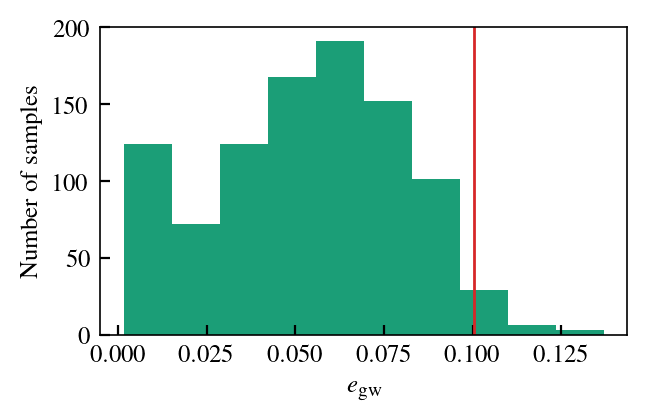

In [26]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

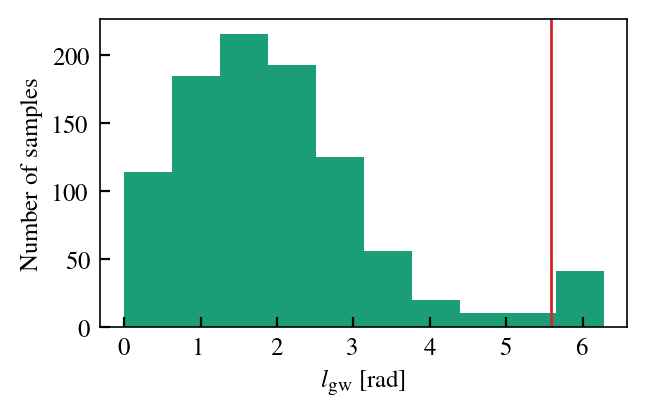

In [27]:
fig, ax = egwBilby.plot_lgw_posterior(usetex=True, style="APS")
ax.axvline(mean_ano_inj, c="tab:red")